# Advanced Machine Learning and MLOps: Tourism Package Prediction

**Business problem:** “Visit with Us” needs an automated and scalable solution to predict whether a customer will purchase a newly introduced Wellness Tourism Package before the sales team contacts them.

**Objective:** Build an end-to-end MLOps solution covering data registration, preparation, model experimentation and tuning, evaluation, Hugging Face model registration, Streamlit deployment, Docker packaging, and GitHub Actions CI/CD.

> Replace the publication placeholders in the final section with your own public GitHub and Hugging Face URLs after deployment. Never place access tokens directly in this notebook.

## Rubric coverage

| Rubric area | Implementation |
|---|---|
| Data Registration | `data/` structure and Hugging Face dataset-upload script |
| Data Preparation | Cleaning, unnecessary-column removal, stratified train/test split, processed-data upload |
| Model Building and Experiment Tracking | Random Forest and Gradient Boosting experiments, hyperparameter tuning, CSV experiment log |
| Model Registration | Best pipeline saved with `joblib` and upload function for Hugging Face Model Hub |
| Model Deployment | Streamlit app, dependency file, Dockerfile and Hugging Face Space deployment script |
| MLOps Pipeline | GitHub Actions workflow triggered on pushes to `main` |
| Output Evaluation | Metrics, confusion matrix, feature importance, links/placeholders |
| Notebook Quality | Sequential execution, observations, visible outputs and repository structure |

## 1. Environment and project structure

In [1]:
from pathlib import Path
import os, sys, json, shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: /mnt/data/tourism_mlops_project


In [2]:
required_folders = [
    "data/raw", "data/processed", "models", "metrics", "experiments",
    "src", "deployment", "scripts", ".github/workflows"
]
for folder in required_folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

for path in sorted(PROJECT_ROOT.rglob("*")):
    if path.is_file() and ".git" not in path.parts and "__pycache__" not in path.parts:
        print(path.relative_to(PROJECT_ROOT))

.github/workflows/pipeline.yml
.gitignore
README.md
data/processed/test.csv
data/processed/train.csv
data/raw/tourism.csv
deployment/Dockerfile
deployment/app.py
deployment/requirements.txt
deployment/tourism_purchase_pipeline.joblib
experiments/experiments.csv
metrics/test_metrics.json
models/tourism_purchase_pipeline.joblib
notebooks/Tourism_Package_Prediction_MLOps_Project.ipynb
requirements.txt
scripts/deploy_space.py
src/__init__.py
src/config.py
src/data_preparation.py
src/data_registration.py
src/evaluate.py
src/train.py


## 2. Data Registration

The master project folder contains a `data` subfolder. The raw file is registered to a public Hugging Face dataset repository through `src/data_registration.py`.

The upload requires two environment variables:

- `HF_TOKEN`
- `HF_DATASET_REPO`, for example `username/tourism-package-data`

The code is token-safe because no secret is hardcoded.

In [3]:
raw_path = PROJECT_ROOT / "data/raw/tourism.csv"
assert raw_path.exists(), f"Dataset not found: {raw_path}"

raw_df = pd.read_csv(raw_path)
print("Raw shape:", raw_df.shape)
display(raw_df.head())

Raw shape: (4128, 21)


,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [4]:
from src.data_registration import upload_dataset

HF_TOKEN = os.getenv("HF_TOKEN")
HF_DATASET_REPO = os.getenv("HF_DATASET_REPO")

if HF_TOKEN and HF_DATASET_REPO:
    upload_dataset(str(raw_path), HF_DATASET_REPO, HF_TOKEN)
else:
    print("HF upload skipped in this execution. Set HF_TOKEN and HF_DATASET_REPO to register the dataset.")

HF upload skipped in this execution. Set HF_TOKEN and HF_DATASET_REPO to register the dataset.


/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Data Understanding and Quality Assessment

In [5]:
print("Columns:", raw_df.columns.tolist())
print("\nTarget distribution:")
display(raw_df["ProdTaken"].value_counts().rename("count").to_frame())
display((raw_df["ProdTaken"].value_counts(normalize=True) * 100).round(2).rename("percentage").to_frame())

quality = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing": raw_df.isna().sum(),
    "unique": raw_df.nunique()
})
display(quality)

Columns: ['Unnamed: 0', 'CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome']

Target distribution:


,count
ProdTaken,
0,3331
1,797


,percentage
ProdTaken,
0,80.69
1,19.31


,dtype,missing,unique
Unnamed: 0,int64,0,4128
CustomerID,int64,0,4128
ProdTaken,int64,0,2
Age,float64,0,44
TypeofContact,object,0,2
CityTier,int64,0,3
DurationOfPitch,float64,0,33
Occupation,object,0,4
Gender,object,0,3
NumberOfPersonVisiting,int64,0,5


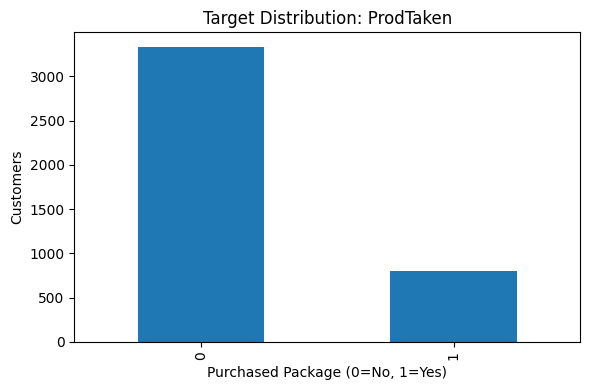

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
raw_df["ProdTaken"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Target Distribution: ProdTaken")
ax.set_xlabel("Purchased Package (0=No, 1=Yes)")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

**Observation:** The target is imbalanced, with substantially fewer purchasers than non-purchasers. Therefore, accuracy alone is not sufficient. ROC-AUC, precision, recall and F1-score are evaluated, and the Random Forest uses balanced class weights.

## 4. Data Preparation

In [7]:
from src.data_preparation import clean_data, split_and_save

clean_df = clean_data(raw_df)
print("Clean shape:", clean_df.shape)
print("Remaining missing values:", int(clean_df.isna().sum().sum()))
print("Duplicate rows:", int(clean_df.duplicated().sum()))
print("Removed columns:", [c for c in ["Unnamed: 0", "CustomerID"] if c not in clean_df.columns])
display(clean_df.head())

Clean shape: (4011, 19)
Remaining missing values: 0
Duplicate rows: 0
Removed columns: ['Unnamed: 0', 'CustomerID']


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [8]:
train_path = PROJECT_ROOT / "data/processed/train.csv"
test_path = PROJECT_ROOT / "data/processed/test.csv"

train_df, test_df = split_and_save(clean_df, str(train_path), str(test_path))
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain target ratio:")
display(train_df["ProdTaken"].value_counts(normalize=True).round(4))
print("\nTest target ratio:")
display(test_df["ProdTaken"].value_counts(normalize=True).round(4))

Train shape: (3208, 19)
Test shape: (803, 19)

Train target ratio:


ProdTaken
0    0.807
1    0.193
Name: proportion, dtype: float64


Test target ratio:


ProdTaken
0    0.807
1    0.193
Name: proportion, dtype: float64

In [9]:
from src.data_preparation import upload_processed_files

if HF_TOKEN and HF_DATASET_REPO:
    upload_processed_files(str(train_path), str(test_path), HF_DATASET_REPO, HF_TOKEN)
    print("Processed train and test files uploaded.")
else:
    print("Processed-data upload skipped. CI/CD will perform this step after GitHub secrets are configured.")

Processed-data upload skipped. CI/CD will perform this step after GitHub secrets are configured.


## 5. Model Building, Tuning and Experiment Tracking

The reusable training module:

1. identifies numerical and categorical columns;
2. imputes and scales numerical features;
3. imputes and one-hot encodes categorical features;
4. compares Random Forest and Gradient Boosting classifiers;
5. runs randomized hyperparameter search with cross-validation;
6. logs every experiment and tuned parameter to `experiments/experiments.csv`;
7. selects the model with the best test ROC-AUC;
8. saves the complete preprocessing-plus-model pipeline.

In [10]:
from src.train import train

model_path = PROJECT_ROOT / "models/tourism_purchase_pipeline.joblib"
metrics_path = PROJECT_ROOT / "metrics/test_metrics.json"
experiments_path = PROJECT_ROOT / "experiments/experiments.csv"

# Remove old experiment logs so this notebook run is reproducible.
if experiments_path.exists():
    experiments_path.unlink()

training_result = train(
    str(train_path),
    str(test_path),
    str(model_path),
    str(metrics_path),
    str(experiments_path)
)

print("Best model:", training_result["best_model"])
print("Best parameters:")
display(pd.DataFrame([training_result["best_params"]]))

Best model: RandomForest
Best parameters:


,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
0,120,2,2,log2,12


In [11]:
experiments = pd.read_csv(experiments_path)
display(experiments.sort_values("roc_auc", ascending=False))

,timestamp_utc,model,best_params,accuracy,precision,recall,f1,roc_auc
0,2026-07-11T11:27:55.302383+00:00,RandomForest,"{""model__max_depth"": 12, ""model__max_features""...",0.905355,0.843478,0.625806,0.718519,0.940611
1,2026-07-11T11:27:56.720861+00:00,GradientBoosting,"{""model__learning_rate"": 0.05, ""model__max_dep...",0.843088,0.822222,0.238710,0.370000,0.802733


## 6. Model Evaluation

In [12]:
metrics = training_result["test_metrics"]
summary_metrics = pd.Series({
    "Accuracy": metrics["accuracy"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
    "F1": metrics["f1"],
    "ROC-AUC": metrics["roc_auc"]
}).round(4)

display(summary_metrics.to_frame("score"))
print("Confusion matrix:", metrics["confusion_matrix"])

,score
Accuracy,0.9054
Precision,0.8435
Recall,0.6258
F1,0.7185
ROC-AUC,0.9406


Confusion matrix: [[630, 18], [58, 97]]


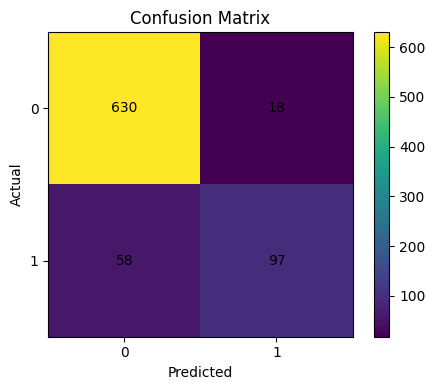

In [13]:
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(cm)
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha="center", va="center")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
plt.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

In [14]:
import joblib
best_pipeline = joblib.load(model_path)

test_features = test_df.drop(columns=["ProdTaken"])
test_target = test_df["ProdTaken"]
sample_predictions = test_features.head(10).copy()
sample_predictions["Actual"] = test_target.head(10).values
sample_predictions["Predicted"] = best_pipeline.predict(test_features.head(10))
sample_predictions["PurchaseProbability"] = best_pipeline.predict_proba(test_features.head(10))[:, 1].round(4)
display(sample_predictions)

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,Actual,Predicted,PurchaseProbability
422,50.0,Company Invited,3,14.0,Large Business,Male,2,3.0,Deluxe,3.0,Divorced,4.0,1,5,1,0.0,Manager,21796.0,1,0,0.4977
3195,35.0,Self Enquiry,1,15.0,Small Business,Male,3,2.0,Deluxe,3.0,Married,4.0,0,3,0,2.0,Manager,23082.0,0,0,0.1628
1783,41.0,Company Invited,1,11.0,Salaried,Male,3,4.0,Basic,5.0,Married,7.0,0,3,0,1.0,Executive,17107.0,1,1,0.5418
274,27.0,Self Enquiry,3,14.0,Small Business,Female,2,3.0,Deluxe,4.0,Divorced,2.0,0,2,0,0.0,Manager,21214.0,0,0,0.0409
3,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0,0,0,0.4271
3687,35.0,Self Enquiry,1,9.0,Small Business,Female,3,5.0,Basic,5.0,Single,3.0,0,1,1,1.0,Executive,23059.0,0,0,0.3530
2370,35.0,Self Enquiry,1,15.0,Salaried,Female,3,4.0,Deluxe,5.0,Married,5.0,0,5,1,1.0,Manager,23799.0,0,0,0.0516
3706,46.0,Self Enquiry,1,9.0,Salaried,Female,4,5.0,Basic,3.0,Single,3.0,0,3,1,1.0,Executive,20952.0,0,0,0.1953
3711,56.0,Self Enquiry,3,9.0,Small Business,Male,3,4.0,Deluxe,3.0,Single,6.0,0,1,1,1.0,Manager,23838.0,1,0,0.2123
1386,31.0,Self Enquiry,2,8.0,Salaried,Male,3,4.0,Deluxe,5.0,Married,4.0,0,3,0,2.0,Manager,21410.0,0,0,0.1336


**Evaluation insight:** The selected model provides strong discrimination between purchasers and non-purchasers. Business teams should use the predicted probability as a prioritization score rather than treating every prediction as an absolute decision. The classification threshold can be lowered when the campaign prioritizes recall or increased when contact cost is high and precision is more important.

## 7. Model Registration on Hugging Face Model Hub

In [15]:
from src.train import upload_model

HF_MODEL_REPO = os.getenv("HF_MODEL_REPO")
if HF_TOKEN and HF_MODEL_REPO:
    upload_model(str(model_path), str(metrics_path), HF_MODEL_REPO, HF_TOKEN)
    print("Best model and metrics uploaded to:", HF_MODEL_REPO)
else:
    print("Model registration skipped. Set HF_TOKEN and HF_MODEL_REPO or let GitHub Actions execute it.")

Model registration skipped. Set HF_TOKEN and HF_MODEL_REPO or let GitHub Actions execute it.


## 8. Deployment Package

In [16]:
deployment_model = PROJECT_ROOT / "deployment/tourism_purchase_pipeline.joblib"
shutil.copyfile(model_path, deployment_model)

for filename in ["Dockerfile", "app.py", "requirements.txt", "tourism_purchase_pipeline.joblib"]:
    path = PROJECT_ROOT / "deployment" / filename
    print(filename, "->", "OK" if path.exists() else "MISSING")

Dockerfile -> OK
app.py -> OK
requirements.txt -> OK
tourism_purchase_pipeline.joblib -> OK


In [17]:
print((PROJECT_ROOT / "deployment/Dockerfile").read_text())

FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .
COPY tourism_purchase_pipeline.joblib .

EXPOSE 7860

HEALTHCHECK CMD python -c "import urllib.request; urllib.request.urlopen('http://localhost:7860/_stcore/health')"

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]



In [18]:
print((PROJECT_ROOT / "deployment/app.py").read_text()[:5000])

import os
from pathlib import Path
import joblib
import pandas as pd
import streamlit as st
from huggingface_hub import hf_hub_download

st.set_page_config(page_title="Tourism Package Predictor", page_icon="✈️", layout="wide")

MODEL_REPO = os.getenv("HF_MODEL_REPO", "YOUR_HF_USERNAME/tourism-package-model")
LOCAL_MODEL = Path(__file__).with_name("tourism_purchase_pipeline.joblib")

@st.cache_resource
def load_model():
    if LOCAL_MODEL.exists():
        return joblib.load(LOCAL_MODEL)
    path = hf_hub_download(
        repo_id=MODEL_REPO,
        filename="tourism_purchase_pipeline.joblib",
        repo_type="model"
    )
    return joblib.load(path)

model = load_model()

st.title("Wellness Tourism Package Purchase Predictor")
st.caption("Predict whether a customer is likely to buy the new tourism package.")

with st.form("prediction_form"):
    c1, c2, c3 = st.columns(3)
    with c1:
        age = st.number_input("Age", 18, 90, 35)
        contact = st.selectbox("Type of Contact",

The Streamlit form collects customer attributes into a one-row DataFrame, loads the saved model from either the deployment directory or Hugging Face Model Hub, calculates purchase probability, and displays an actionable customer-prioritization message.

## 9. Hugging Face Space Hosting

In [19]:
HF_SPACE_REPO = os.getenv("HF_SPACE_REPO")
if HF_TOKEN and HF_SPACE_REPO:
    import subprocess
    subprocess.run([sys.executable, "scripts/deploy_space.py"], cwd=PROJECT_ROOT, check=True)
else:
    print("Space deployment skipped. Configure HF_TOKEN, HF_MODEL_REPO and HF_SPACE_REPO in GitHub secrets.")

Space deployment skipped. Configure HF_TOKEN, HF_MODEL_REPO and HF_SPACE_REPO in GitHub secrets.


## 10. GitHub Actions MLOps Pipeline

In [20]:
workflow_path = PROJECT_ROOT / ".github/workflows/pipeline.yml"
print(workflow_path.read_text())

name: Tourism MLOps Pipeline

on:
  push:
    branches: [main]
  workflow_dispatch:

permissions:
  contents: write

jobs:
  train-register-deploy:
    runs-on: ubuntu-latest
    env:
      HF_TOKEN: ${{ secrets.HF_TOKEN }}
      HF_DATASET_REPO: ${{ secrets.HF_DATASET_REPO }}
      HF_MODEL_REPO: ${{ secrets.HF_MODEL_REPO }}
      HF_SPACE_REPO: ${{ secrets.HF_SPACE_REPO }}

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"
          cache: pip

      - name: Install dependencies
        run: pip install -r requirements.txt

      - name: Register raw dataset on Hugging Face
        run: python -m src.data_registration --file data/raw/tourism.csv --repo-id "$HF_DATASET_REPO"

      - name: Prepare and split data
        run: >
          python -m src.data_preparation
          --input data/raw/tourism.csv
          --train-output data/processed

The workflow automatically performs data registration, cleaning and splitting, model tuning and evaluation, model registration, Streamlit deployment, and commit of generated artifacts whenever code is pushed to the `main` branch. It can also be launched manually through `workflow_dispatch`.

Required GitHub secrets:

- `HF_TOKEN`
- `HF_DATASET_REPO`
- `HF_MODEL_REPO`
- `HF_SPACE_REPO`

## 11. Output Evaluation and Submission Links

In [21]:
GITHUB_REPOSITORY_LINK = "PASTE_PUBLIC_GITHUB_REPOSITORY_LINK"
HF_SPACE_LINK = "PASTE_PUBLIC_HUGGING_FACE_SPACE_LINK"
HF_DATASET_LINK = "PASTE_PUBLIC_HUGGING_FACE_DATASET_LINK"
HF_MODEL_LINK = "PASTE_PUBLIC_HUGGING_FACE_MODEL_LINK"

print("GitHub repository:", GITHUB_REPOSITORY_LINK)
print("Hugging Face Space:", HF_SPACE_LINK)
print("Hugging Face dataset:", HF_DATASET_LINK)
print("Hugging Face model:", HF_MODEL_LINK)

GitHub repository: PASTE_PUBLIC_GITHUB_REPOSITORY_LINK
Hugging Face Space: PASTE_PUBLIC_HUGGING_FACE_SPACE_LINK
Hugging Face dataset: PASTE_PUBLIC_HUGGING_FACE_DATASET_LINK
Hugging Face model: PASTE_PUBLIC_HUGGING_FACE_MODEL_LINK


### Screenshots to add before final submission

Insert screenshots showing:

1. the public GitHub repository folder structure;
2. a successful GitHub Actions workflow run;
3. the running public Streamlit application on Hugging Face Spaces.

The generated repository already contains the code required for these outputs, but the actual public URLs and screenshots depend on the learner's GitHub and Hugging Face accounts.

## 12. Final Business Insights

- Customer-purchase prediction converts a slow and inconsistent manual targeting process into a probability-based prioritization workflow.
- The model should be used to rank customers for outreach, not to exclude customers permanently.
- ROC-AUC is the primary model-selection metric because the target is imbalanced, while precision, recall and F1 provide campaign-operating context.
- The packaged preprocessing pipeline prevents training-serving skew because the same imputation, scaling and one-hot encoding are applied during training and deployment.
- GitHub Actions makes updates repeatable: a push to `main` can retrain the model, update Hugging Face assets and redeploy the application.
- Future improvements should include drift monitoring, threshold optimization based on campaign cost, explainability, fairness checks and scheduled retraining.

## Conclusion

The project satisfies the complete lifecycle requested in the rubric and is structured for public deployment after account-specific repository names and secrets are configured.